In [1]:
import tensorflow as tf

import os
from pathlib import Path
import datetime
import numpy as np
import random


from IPython.display import display, clear_output
from tqdm.notebook import tqdm

from fid import get_frechet_inception_distance
import pandas as pd

from normalize import images_from_normalized
from data_generator import FrameDataGenerator, PreprocessedFrameDataGenerator
from plot import plot_normalized_sequence, generate_sequences, plot_results
from model import get_generator_model, get_discriminator_model
from loss import l1_loss, euclidean_distance, GeneratorLoss, DiscriminatorLoss, pairwise_loss
from landmarks import DlibLandmarksDetector

2023-06-16 17:47:07.624600: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-06-16 17:47:07.674816: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
COHERENCE_LOSS = None # TODO: loss function not working, fix: str > function
MAIN_LOSS = l1_loss
LANDMARKS_LOSS = None
LANDMARKS_COHERENCE_LOSS = None

# Dimensions
r = 64
# BATCH_SIZE = 100 # TODO: Allow only 1 frame input
IMG_WIDTH = r
IMG_HEIGHT = r
N_CHANNELS = 3

N_LANDMARKS = 68


STEPS = 100000
# STEPS = STEPS // BATCH_SIZE
STEPS = STEPS // 100

LAMBDA1 = 1000
LAMBDA2 = 200
LAMBDA3 = 100
LAMBDA4 = 10

VIDEOS_FOLDER = f'mug{r}'
BASE_PATH = Path('../')
DATA_PATH = BASE_PATH / 'data'
APP_PATH = BASE_PATH / 'app'


## Load the dataset

In [3]:
videos_path = list((DATA_PATH / VIDEOS_FOLDER).glob('**/*.npy'))

In [4]:
DATASET_SIZE = len(videos_path)
train_size = int(0.7 * DATASET_SIZE)
# val_size = int(0.15 * DATASET_SIZE)
test_size = int(0.3 * DATASET_SIZE)

# generate training, validation and test sets
train_paths = videos_path[:train_size]
# val_sequences = sequences[train_size:train_size+val_size]
# test_sequences = sequences[train_size+val_size:]
test_paths = videos_path[train_size:]

tf.print(len(train_paths))
tf.print(len(test_paths))

# shuffle list of paths
random.shuffle(train_paths)
random.shuffle(test_paths)

722
310


2023-06-16 17:47:12.647570: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2023-06-16 17:47:12.647672: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:168] retrieving CUDA diagnostic information for host: 9900cbbf9a77
2023-06-16 17:47:12.647695: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:175] hostname: 9900cbbf9a77
2023-06-16 17:47:12.647890: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:199] libcuda reported version is: NOT_FOUND: was unable to find libcuda.so DSO loaded into this program
2023-06-16 17:47:12.647950: I tensorflow/compiler/xla/stream_executor/cuda/cuda_diagnostics.cc:203] kernel reported version is: 525.105.17


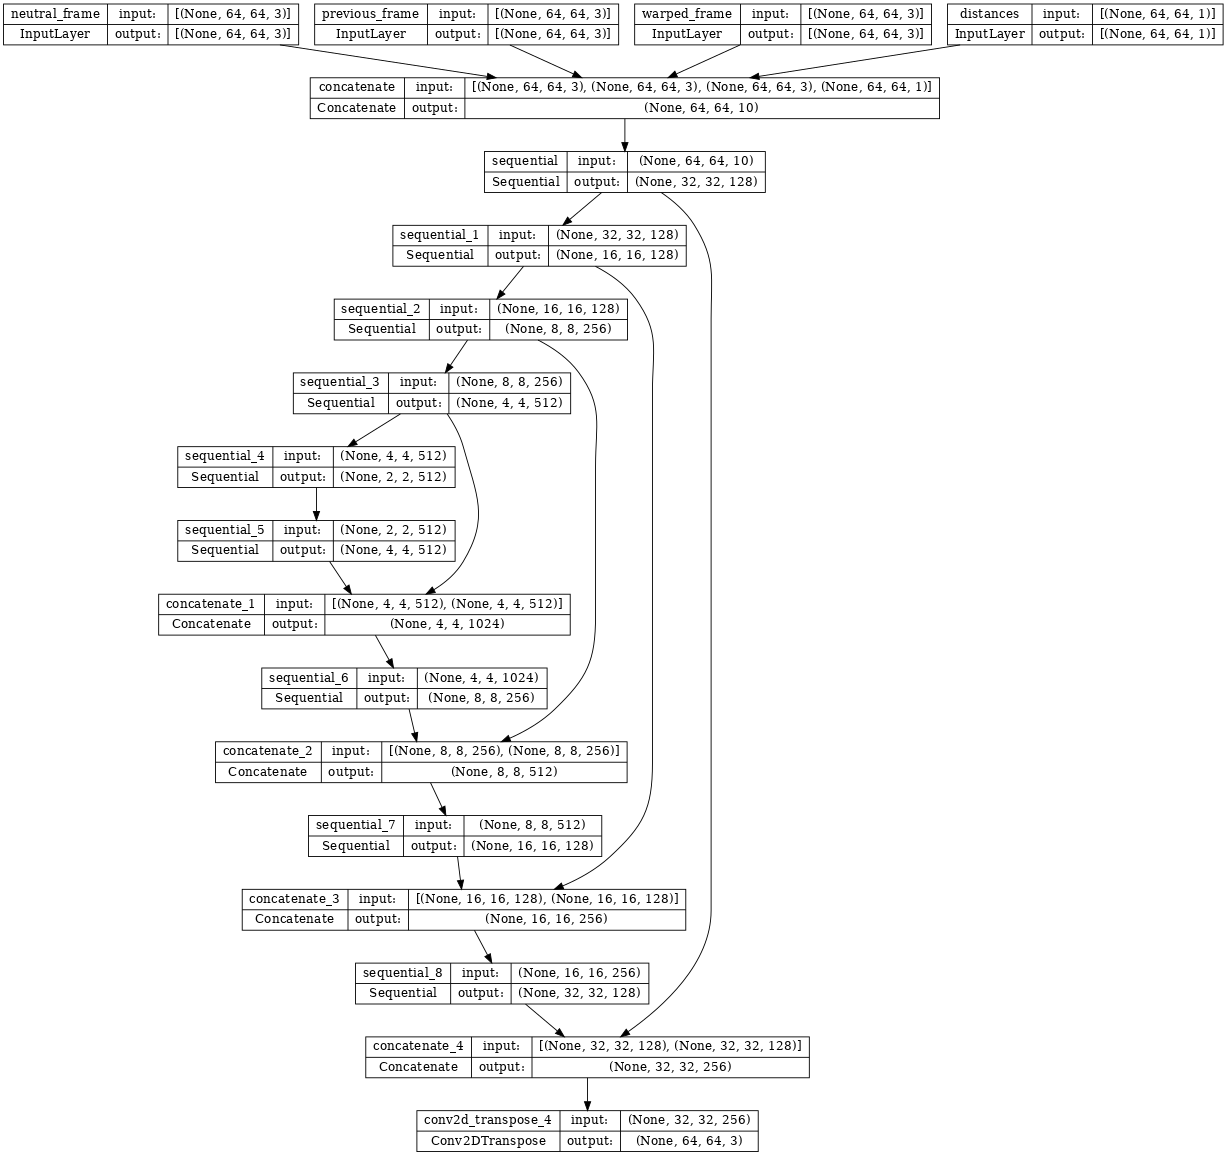

In [5]:
generator = get_generator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(generator, show_shapes=True, dpi=64, to_file='output/generator.png')

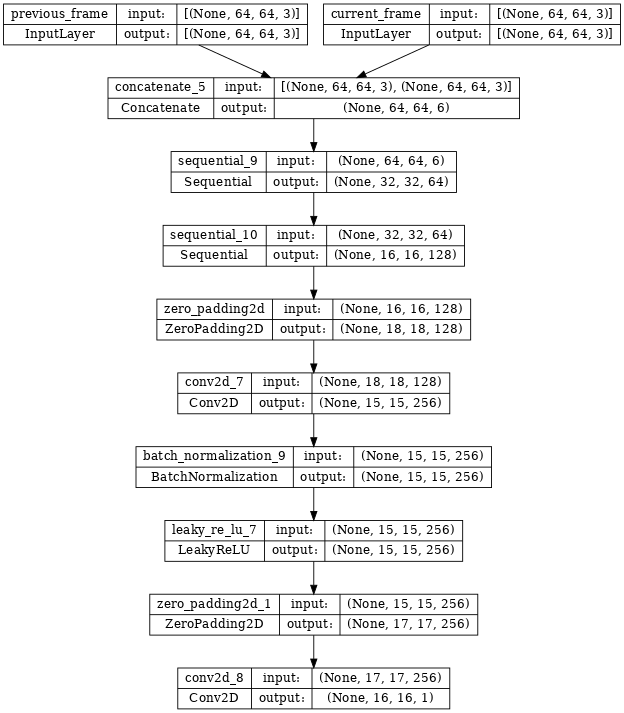

In [6]:
discriminator = get_discriminator_model(IMG_WIDTH, IMG_HEIGHT, N_CHANNELS)
tf.keras.utils.plot_model(discriminator, show_shapes=True, dpi=64, to_file='output/discriminator.png')

In [7]:
generator_loss = GeneratorLoss(MAIN_LOSS,
                lambda_main_loss=LAMBDA1,
                coherence_loss_function=COHERENCE_LOSS,
                lambda_coherence_loss=LAMBDA2,
                landmarks_loss_function=None,
                lambda_landmarks_loss=0,
                landmarks_coherence_loss_function=LANDMARKS_COHERENCE_LOSS,
                lambda_landmarks_coherence_loss=LAMBDA4)

In [8]:
discriminator_loss = DiscriminatorLoss()

In [9]:
generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [10]:
id_string = ""
if MAIN_LOSS:
    id_string += f"{MAIN_LOSS.__name__}_{LAMBDA1}"
if COHERENCE_LOSS:
    id_string += f"_{COHERENCE_LOSS.__name__}_{LAMBDA2}"
if LANDMARKS_LOSS:
    id_string += f"_{LANDMARKS_LOSS.__name__}_{LAMBDA3}"
if LANDMARKS_COHERENCE_LOSS:
    id_string += f"_{LANDMARKS_COHERENCE_LOSS.__name__}_{LAMBDA4}"
id_string

'l1_loss_1000'

In [11]:
BASE_DIR = APP_PATH / 'output' / id_string
checkpoint_dir = str(BASE_DIR / 'training_checkpoints')
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer,
                                 discriminator_optimizer=discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

## Training


In [12]:
log_dir=BASE_DIR / "logs/"
log_file = log_dir / "fit" / datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

summary_writer = tf.summary.create_file_writer(str(log_file))

In [13]:
def fit(train_dataset_generator, test_dataset_generator, steps):
  pbar = tqdm(range(steps), total=steps)
  for step in pbar:
    with tf.profiler.experimental.Trace('train', step_num=step, _r=1):

      if (step) % 5 == 0:
        clear_output(wait=True)
        display(pbar.container)
        previously_generated, generated_frame, sample_target = test_dataset_generator.generate_next_frame()
        plot_results(sample_target, previously_generated, generated_frame) # TODO: fix input and ground truth are not from the same video

      # train_step(train_dataset_generator, step)
      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        gen_total_loss, disc_loss, gen_gan_loss, gen_target_predicted, gen_coherence_loss, gen_landmarks_loss, gen_landmarks_coherence_loss = train_dataset_generator.next_loss()
        generator_gradients = gen_tape.gradient(gen_total_loss,
                                                generator.trainable_variables)
        discriminator_gradients = disc_tape.gradient(disc_loss,
                                                    discriminator.trainable_variables)

        generator_optimizer.apply_gradients(zip(generator_gradients,
                                                generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(discriminator_gradients,
                                                    discriminator.trainable_variables))
        with summary_writer.as_default():
          tf.summary.scalar(f'gen_total_loss', gen_total_loss, step=step)
          tf.summary.scalar(f'gen_gan_loss', gen_gan_loss, step=step)
          tf.summary.scalar(f'disc_loss', disc_loss, step=step)
          if generator_loss.main_loss_function:
            tf.summary.scalar(f'gen_target_predicted', gen_target_predicted, step=step)
          if generator_loss.coherence_loss_function:
            tf.summary.scalar(f'gen_coherence', gen_coherence_loss, step=step)
          if generator_loss.landmarks_loss_function:
            tf.summary.scalar(f'gen_landmarks_loss', gen_landmarks_loss, step=step)
          if generator_loss.landmarks_coherence_loss_function:
            tf.summary.scalar(f'gen_landmarks_coherence_loss', gen_landmarks_coherence_loss, step=step)
      
      # Save (checkpoint) the model every 5k steps
      if (step + 1) % 50 == 0:
          checkpoint.save(file_prefix=checkpoint_prefix)

In [14]:
train_generator = PreprocessedFrameDataGenerator(train_paths, generator, discriminator, generator_loss, discriminator_loss, repeat=True)
test_generator = PreprocessedFrameDataGenerator(test_paths, generator, discriminator, generator_loss, discriminator_loss)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [15]:
tf.profiler.experimental.start(str(log_dir))

2023-06-16 17:47:17.262326: I tensorflow/tsl/profiler/lib/profiler_session.cc:104] Profiler session initializing.
2023-06-16 17:47:17.262409: I tensorflow/tsl/profiler/lib/profiler_session.cc:119] Profiler session started.


100%|#########9| 995/1000 [08:32<00:02,  2.08it/s]

Input Sequence


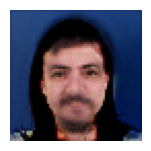

Ground Truth


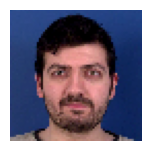

Predicted Sequence


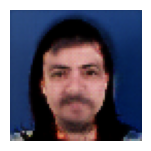

In [16]:
fit(train_generator, test_generator, steps=STEPS)

## Restore the latest checkpoint and test the network

In [17]:
!ls {checkpoint_dir}

checkpoint		     ckpt-19.data-00000-of-00001
ckpt-1.data-00000-of-00001   ckpt-19.index
ckpt-1.index		     ckpt-2.data-00000-of-00001
ckpt-10.data-00000-of-00001  ckpt-2.index
ckpt-10.index		     ckpt-20.data-00000-of-00001
ckpt-11.data-00000-of-00001  ckpt-20.index
ckpt-11.index		     ckpt-3.data-00000-of-00001
ckpt-12.data-00000-of-00001  ckpt-3.index
ckpt-12.index		     ckpt-4.data-00000-of-00001
ckpt-13.data-00000-of-00001  ckpt-4.index
ckpt-13.index		     ckpt-5.data-00000-of-00001
ckpt-14.data-00000-of-00001  ckpt-5.index
ckpt-14.index		     ckpt-6.data-00000-of-00001
ckpt-15.data-00000-of-00001  ckpt-6.index
ckpt-15.index		     ckpt-7.data-00000-of-00001
ckpt-16.data-00000-of-00001  ckpt-7.index
ckpt-16.index		     ckpt-8.data-00000-of-00001
ckpt-17.data-00000-of-00001  ckpt-8.index
ckpt-17.index		     ckpt-9.data-00000-of-00001
ckpt-18.data-00000-of-00001  ckpt-9.index
ckpt-18.index


In [18]:
# Restoring the latest checkpoint in checkpoint_dir
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

## Generate some images using the test set

Input Sequence


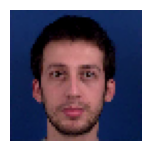

Ground Truth


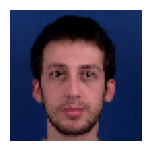

Predicted Sequence


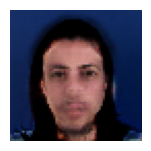

Input Sequence


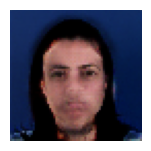

Ground Truth


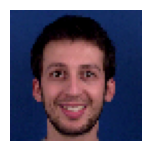

Predicted Sequence


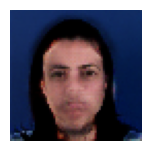

Input Sequence


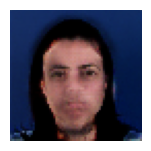

Ground Truth


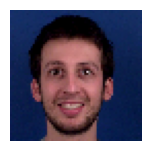

Predicted Sequence


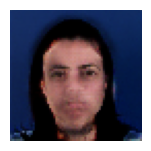

Input Sequence


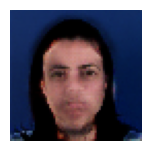

Ground Truth


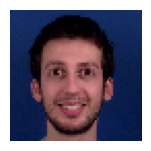

Predicted Sequence


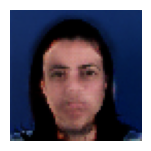

Input Sequence


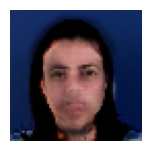

Ground Truth


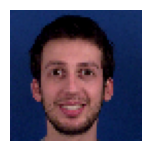

Predicted Sequence


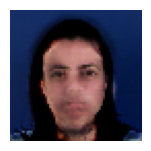

Input Sequence


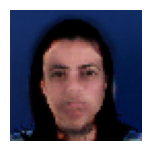

Ground Truth


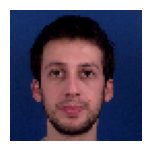

Predicted Sequence


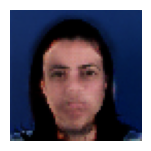

Input Sequence


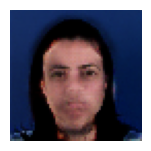

Ground Truth


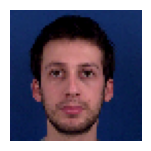

Predicted Sequence


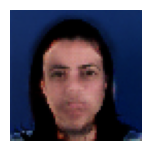

Input Sequence


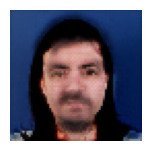

Ground Truth


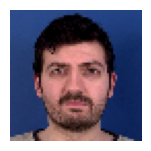

Predicted Sequence


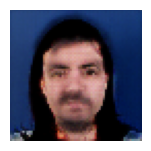

Input Sequence


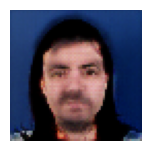

Ground Truth


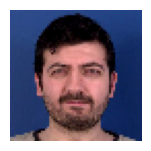

Predicted Sequence


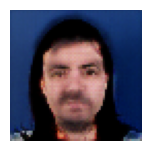

Input Sequence


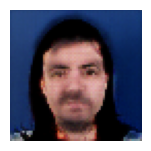

Ground Truth


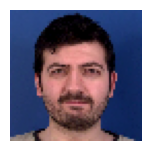

Predicted Sequence


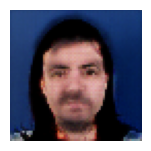

In [19]:
test_generator.restart()
for i in range(0,1000,10):
  previously_generated, generated_frame, sample_target = test_generator.generate_next_frame()
  if i % 100 == 0:
    plot_results(sample_target, previously_generated, generated_frame)

In [20]:
# adapted from https://gist.github.com/lukoshkin/6205455d5b931dcdbd923323003058f0 
# and https://github.com/valerystrizh/mocogan_modified/blob/0860daaa6564b563b5acc1d88f19bac051c1d1c6/src/metrics.py
def acd(frames):
    N = np.multiply.reduce(frames.shape[1:-1])
    res = np.mean(
            np.linalg.norm(
              np.diff(
                np.einsum('ijkl->il', frames), 
              axis=0) / N, 
            axis=1)
          ) 

    return res

def compare_acd(target_sequence, generated_output):
    return np.abs(acd(target_sequence) - acd(generated_output))

In [21]:
# evaluating the results with SSIM
def evaluate_metrics(target_sequence, generated_output, batch_size):
    unormalize_target_sequence = images_from_normalized(target_sequence)
    unormalize_generated_output = images_from_normalized(generated_output)
    #cast to float32
    target_sequence = tf.cast(target_sequence, tf.float32)
    generated_output = tf.cast(generated_output, tf.float32)
    #compute ssim
    ssim_scores = tf.image.ssim(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute psnr
    psnr_scores = tf.image.psnr(unormalize_target_sequence, unormalize_generated_output, max_val=255)
    #compute mse
    mse_scores = tf.keras.losses.MSE(target_sequence, generated_output)
    #compute l1
    l1_scores = tf.keras.losses.MAE(target_sequence, generated_output)
    # compute fid
    fid_scores = get_frechet_inception_distance(unormalize_target_sequence, unormalize_generated_output, batch_size=batch_size, num_inception_images=batch_size) # TODO: pre frame
    # compute fvd
    # fvd_scores = calculate_fvd(unormalize_target_sequence, unormalize_generated_output)
    # compute acd
    acd_scores = compare_acd(unormalize_target_sequence, unormalize_generated_output) # TODO: per video
    return  {
        "SSIM": tf.reduce_mean(ssim_scores).numpy(),
        "PSNR": tf.reduce_mean(psnr_scores).numpy(),
        "MSE": tf.reduce_mean(mse_scores).numpy(),
        "L1": tf.reduce_mean(l1_scores).numpy(),
        # "FVD": fvd_scores
        "FID": fid_scores.numpy(),
        "ACD": acd_scores
    }


test_n_frames = 500
test_generator.restart()
predicted_frames = []
target_frames = []

for i in tqdm(range(0, test_n_frames)):
    _, predicted_frame, target_frame = test_generator.generate_next_frame()
    predicted_frames.append(predicted_frame[0])
    target_frames.append(target_frame[0])

predicted_frames = np.array(predicted_frames)
target_frames = np.array(target_frames)

batch_size = 100
scores = []
for i in tqdm(range(0, test_n_frames, batch_size)):
    print(target_frames[i:i+batch_size].shape)
    scores.append(evaluate_metrics(target_frames[i:i+batch_size], predicted_frames[i:i+batch_size], batch_size=batch_size))
  

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

(100, 64, 64, 3)
Instructions for updating:
back_prop=False is deprecated. Consider using tf.stop_gradient instead.
Instead of:
results = tf.map_fn(fn, elems, back_prop=False)
Use:
results = tf.nest.map_structure(tf.stop_gradient, tf.map_fn(fn, elems))


/usr/local/lib/python3.8/dist-packages/tensorflow/python/util/nest.py:917: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  structure[0], [func(*x) for x in entries],


(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)
(100, 64, 64, 3)


In [22]:
len(scores)
df = pd.DataFrame(scores)
df.to_csv(f"{log_dir}/metrics.csv")
print(df)

       SSIM       PSNR       MSE        L1         FID       ACD
0  0.531682  17.628569  0.071639  0.155195  212.567688  0.001869
1  0.552305  18.563122  0.061631  0.140201  299.451324  0.000776
2  0.556749  17.268141  0.082817  0.171673  297.479553  0.001404
3  0.641483  21.119091  0.030917  0.115502  282.779083  0.000304
4  0.577882  20.184155  0.038852  0.124567  312.002197  0.003091


In [23]:
print(df.mean())

SSIM      0.572020
PSNR     18.952616
MSE       0.057171
L1        0.141427
FID     280.855988
ACD       0.001489
dtype: float64


## Different order

In [24]:
new_order = [0, 10, 1, 11, 2, 12, 3, 13, 4, 14, 5, 15, 6, 16, 7, 17, 8, 18, 9]

# # Run the trained model on a few examples from the test set
# for i, (inp, tar) in enumerate(test_dataset.take(5)):
#   inp = tf.gather(inp, new_order, axis=-1)
#   tar = tf.gather(tar, new_order, axis=-1)
#   # inp = inp[..., new_order]
#   # tar = tar[..., new_order]
#   tf.print(i)
#   generate_sequences(generator, inp, tar, save_dir=save_dir)